g:\mp\Decoding-Au-clusters\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading data from: g:\mp\Decoding-Au-clusters\dimredpy_vs_others\dimredpy_vs_umap\..\subset_10000.txt
Data shape: (1500, 13)
Metric: mahalanobis
Nearest Neighbors: 15
Minimum Distance: 0.1

          RUNNING REFERENCE FRAMEWORK (umap-learn)
-> Reference execution finished.

          RUNNING DIMREDPY FRAMEWORK
-> DimRedPy execution finished.

          PARITY VALIDATION
1. Projection Coordinates MSE : 0.000000e+00
2. Procrustes Disparity       : 9.612881e-32
3. Pearson Correlation (R)    : 1.000000

SUCCESS: DimRedPy UMAP Projection is mathematically equivalent.


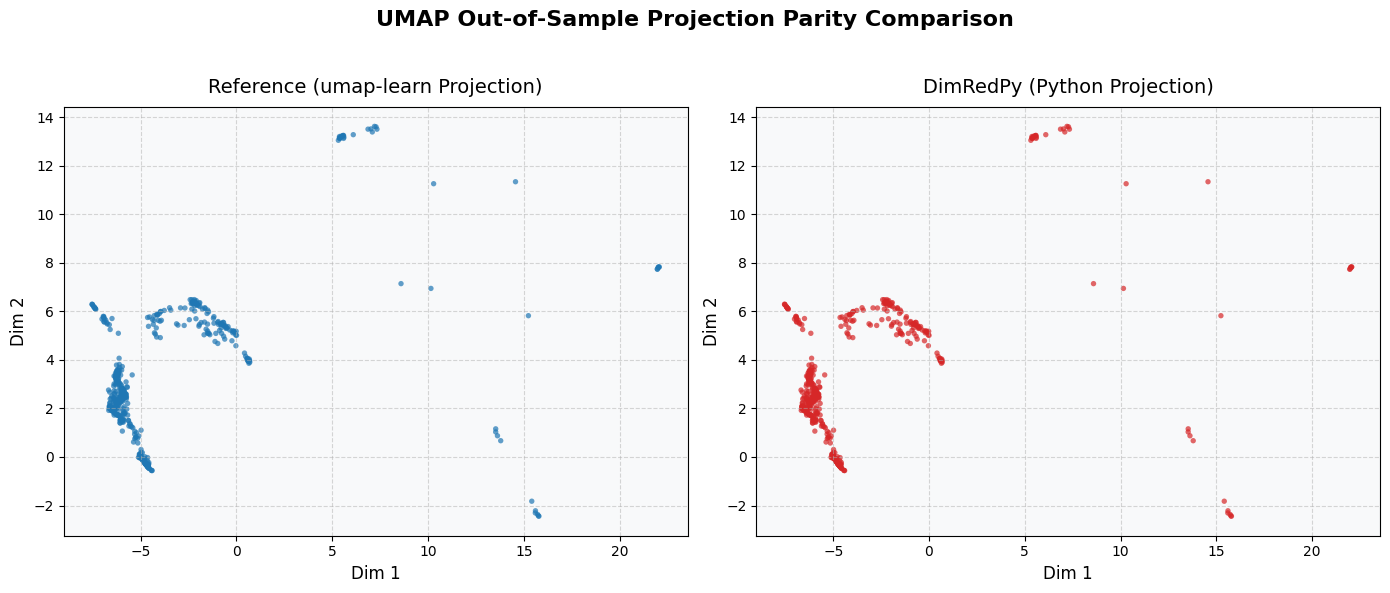

Saved comparison plot to g:\mp\Decoding-Au-clusters\dimredpy_vs_others\dimredpy_vs_umap\verify_parity_umap_projection_plot.png


In [1]:
"""
Rigorous Verification of UMAP Out-of-Sample Projection (DimRedPy vs umap-learn)

This script validates that the DimRedPy framework produces mathematically identical results
to the underlying umap-learn reference implementation for out-of-sample projection.
We utilize rigorous statistical metrics:
1. Projection Coordinates MSE (Compares projected coordinates)
2. Procrustes Disparity (Measures shape disparity independent of translation/rotation)
3. Pearson Correlation (Global structure correlation between embeddings)
"""

import numpy as np
import matplotlib.pyplot as plt
import os
import sys

import umap
from scipy.spatial import procrustes
from scipy.stats import pearsonr

# Robust path detection for repo root
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
repo_root = os.path.abspath(os.path.join(script_dir, "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from dimredpy.umap_embed import umap_embed, umap_project

# ---------------------------------------------------------------------------
# 1. Load the Dataset
# ---------------------------------------------------------------------------
candidate_paths = [
    os.path.join(script_dir, "..", "subset_10000.txt"),
    os.path.join(os.getcwd(), "subset_10000.txt"),
    os.path.join(os.getcwd(), "dimredpy_vs_others", "subset_10000.txt")
]

data_path = None
for p in candidate_paths:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("Could not find subset_10000.txt in any expected location.")

print(f"Loading data from: {data_path}")
data = np.loadtxt(data_path, max_rows=1500)
print(f"Data shape: {data.shape}")

pool_data = data[:1000]
samples = data[1000:1500]

# ---------------------------------------------------------------------------
# 2. Define Shared Hyperparameters
# ---------------------------------------------------------------------------
metric = "mahalanobis"
n_neighbors = 15
min_dist = 0.1
random_state = 42

print(f"Metric: {metric}")
print(f"Nearest Neighbors: {n_neighbors}")
print(f"Minimum Distance: {min_dist}")

# ---------------------------------------------------------------------------
# 3. Run Reference Framework (umap-learn)
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING REFERENCE FRAMEWORK (umap-learn)")
print("=======================================================")

X_ref = np.asarray(pool_data, dtype=float)
cov = np.cov(X_ref, rowvar=False)
cov += np.eye(cov.shape[0]) * 1e-6

reducer = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=min_dist,
    metric=metric,
    metric_kwds={"V": cov},
    random_state=random_state,
    n_jobs=1,
)

emb_ref = reducer.fit_transform(pool_data)
ref_proj = reducer.transform(samples)
print("-> Reference execution finished.")

# ---------------------------------------------------------------------------
# 4. Run DimRedPy Framework
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING DIMREDPY FRAMEWORK")
print("=======================================================")

res_dimredpy = umap_embed(
    pool_data,
    n_components=2,
    metric=metric,
    n_neighbors=n_neighbors,
    min_dist=min_dist,
    seed=random_state,
    n_jobs=1,
    use_gpu=False, # Force CPU to match umap-learn exactly
)
emb_dimredpy = res_dimredpy["embedding"]
py_proj = umap_project(res_dimredpy, samples)
print("-> DimRedPy execution finished.")

# ---------------------------------------------------------------------------
# 5. Rigorous Parity Validation
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          PARITY VALIDATION")
print("=======================================================")

mse = np.mean((ref_proj - py_proj)**2)
_, _, disparity = procrustes(ref_proj, py_proj)
corr, _ = pearsonr(ref_proj.flatten(), py_proj.flatten())

print(f"1. Projection Coordinates MSE : {mse:.6e}")
print(f"2. Procrustes Disparity       : {disparity:.6e}")
print(f"3. Pearson Correlation (R)    : {corr:.6f}")

if mse < 1e-10 and disparity < 1e-10 and corr > 0.99999:
    print("\nSUCCESS: DimRedPy UMAP Projection is mathematically equivalent.")
else:
    print("\nFAILURE: Statistical divergence detected in Projection.")

# ---------------------------------------------------------------------------
# 6. Visual Verification
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

axes[0].scatter(ref_proj[:, 0], ref_proj[:, 1], s=15, alpha=0.7, c='#1f77b4', edgecolors='none')
axes[0].set_title("Reference (umap-learn Projection)", fontsize=14, pad=10)
axes[0].set_xlabel("Dim 1", fontsize=12)
axes[0].set_ylabel("Dim 2", fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].set_facecolor('#f8f9fa')

axes[1].scatter(py_proj[:, 0], py_proj[:, 1], s=15, alpha=0.7, c='#d62728', edgecolors='none')
axes[1].set_title("DimRedPy (Python Projection)", fontsize=14, pad=10)
axes[1].set_xlabel("Dim 1", fontsize=12)
axes[1].set_ylabel("Dim 2", fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].set_facecolor('#f8f9fa')

plt.suptitle("UMAP Out-of-Sample Projection Parity Comparison", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])

plot_path = os.path.join(script_dir, "verify_parity_umap_projection_plot.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved comparison plot to {plot_path}")
